✅ Loaded: /content/maintence_dataset_final_hijri_added_and0prio.xlsx
Shape: (8238, 28)
Columns: ['hijri_day', 'hijri_month', 'hijri_year', 'days_type', 'site', 'priority', 'sector', 'incident_time', 'severity_category', 'fault_alarmandactivity', 'need_spare_parts', 'maintenance_type', 'responsible_team', 'team_location', 'no_technicians_at_time_of_maintance', 'distance_to_site_km', 'need_cars', 'no_of_cars', 'technicians_count', 'time_in', 'time_out', 'downtime_hours', 'work_hours', 'part_category', 'inspection_result', 'risk_before_%', 'risk_after_%', 'under_warranty']

✅ Using Features:
NUM_COLS: ['no_technicians_at_time_of_maintance']
CAT_COLS: ['site', 'severity_category']
TEXT_COL: fault_alarmandactivity


,hijri_day,hijri_month,hijri_year,days_type,site,priority,sector,incident_time,severity_category,fault_alarmandactivity,...,technicians_count,time_in,time_out,downtime_hours,work_hours,part_category,inspection_result,risk_before_%,risk_after_%,under_warranty
0,27.0,6.0,1445.0,week days,r207,4,dawadmi,0.106944,minor,installation of repaired injection pump of sla...,...,2,04:37:00,06:41:00,4,2011,replaced,pass,40,0,yes
1,1.0,9.0,1446.0,weekend days,r056,4,dawadmi,0.3875,minor,power cable,...,2,11:08:00,11:46:00,12,2649,replaced,pass,24,0,yes
2,27.0,8.0,1445.0,weekend days,r151,4,muzahamiyah,0.540972,minor,power cable,...,1,08:26:00,11:22:00,11,2804,replaced,pass,37,0,yes
3,29.0,6.0,1445.0,week days,r194,4,majmaah,0.484722,minor,diesel manual refuel.,...,2,13:05:00,14:44:00,4,2201,no_need,pass,21,0,yes
4,4.0,10.0,1446.0,week days,r133,4,riyadh 1,0.540972,minor,installation of repaired injection pump of sla...,...,2,14:21:00,17:16:00,7,1512,fixed,needs rework,26,0,yes



✅ Dataset Summary Table


,Column,Data Type,Missing Values,Missing %,Unique Values
0,hijri_day,float64,36,0.44,30
1,hijri_month,float64,36,0.44,12
2,hijri_year,float64,36,0.44,3
3,days_type,object,36,0.44,2
4,site,object,0,0.00,657
5,priority,int64,0,0.00,5
6,sector,object,5,0.06,355
7,incident_time,object,0,0.00,1722
8,severity_category,object,0,0.00,8
9,fault_alarmandactivity,object,2,0.02,513


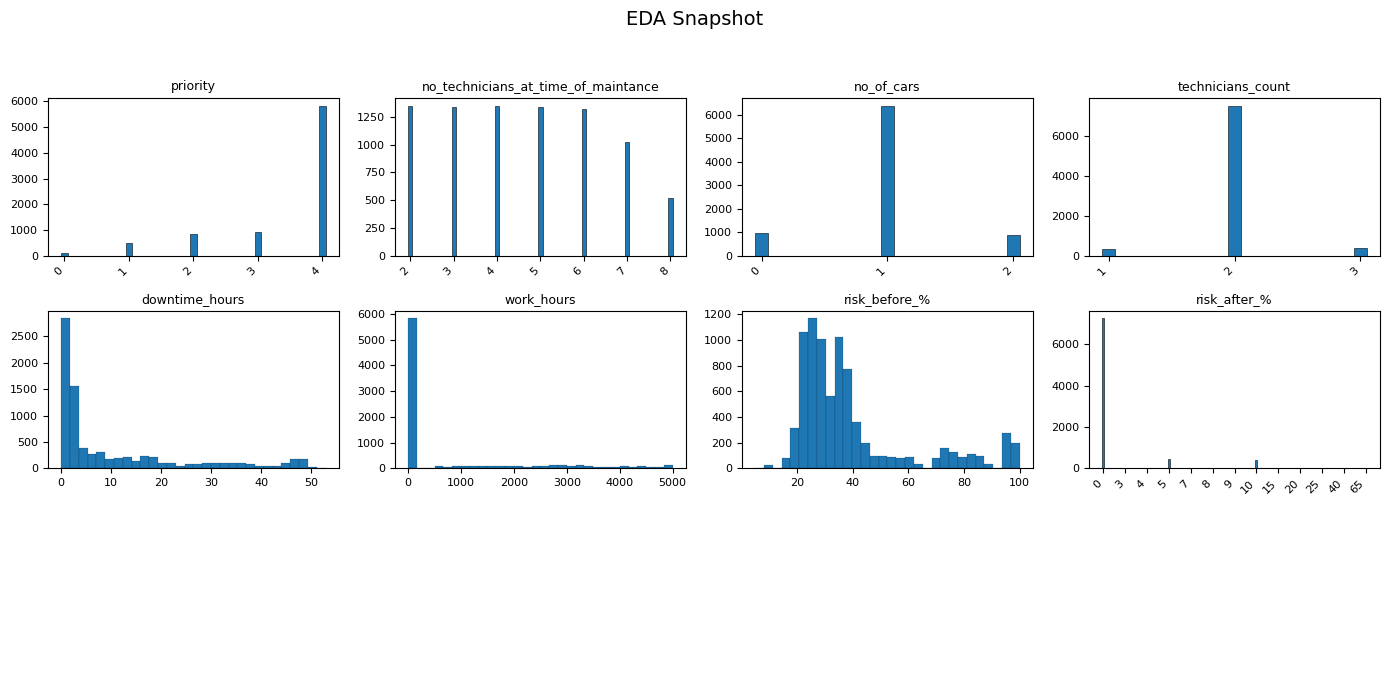

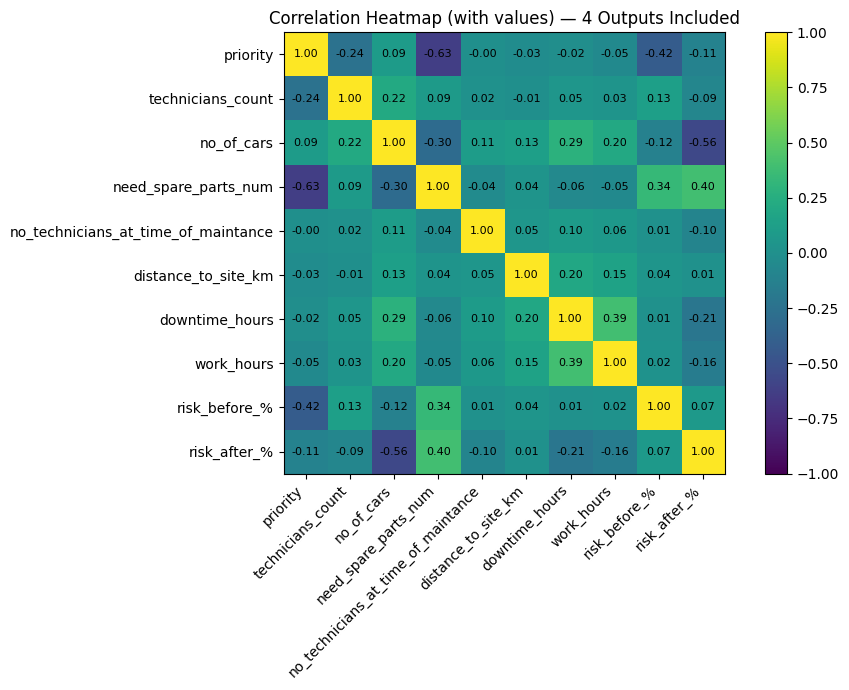

✅ Note: 'need_spare_parts_num' is encoded from 'need_spare_parts' as 0/1 for correlation.

✅ Pre-training candidates:
Numeric cols: 10
Categorical cols: 13
Text col: fault_alarmandactivity

===== TOP 20 (TOP IMPORTANT FEATURES) for technicians_count =====


,feature,score,type
0,distance_to_site_km,1.000000,numeric
1,site,1.000000,categorical
2,risk_before_%,0.872963,numeric
3,risk_after_%,0.638353,numeric
4,downtime_hours,0.544085,numeric
5,work_hours,0.504118,numeric
6,maintenance_type,0.459729,categorical
7,need_cars,0.448344,categorical
8,severity_category,0.397287,categorical
9,team_location,0.381404,categorical



===== TOP 20 (TOP IMPORTANT FEATURES) for priority =====


,feature,score,type
0,distance_to_site_km,1.000000,numeric
1,site,1.000000,categorical
2,risk_before_%,0.970222,numeric
3,severity_category,0.633084,categorical
4,downtime_hours,0.562306,numeric
5,work_hours,0.436030,numeric
6,maintenance_type,0.304306,categorical
7,incident_time,0.260795,numeric
8,risk_after_%,0.210863,numeric
9,time_out,0.125242,categorical



===== TOP 20 (TOP IMPORTANT FEATURES) for no_of_cars =====


,feature,score,type
0,risk_after_%,1.000000,numeric
1,site,1.000000,categorical
2,distance_to_site_km,0.968793,numeric
3,downtime_hours,0.868303,numeric
4,work_hours,0.783781,numeric
5,sector,0.729259,categorical
6,time_out,0.727738,categorical
7,time_in,0.673452,categorical
8,team_location,0.606053,categorical
9,need_cars,0.568632,categorical



===== TOP 20 (TOP IMPORTANT FEATURES) for need_spare_parts =====


,feature,score,type
0,distance_to_site_km,1.000000,numeric
1,site,1.000000,categorical
2,downtime_hours,0.854023,numeric
3,risk_before_%,0.779402,numeric
4,work_hours,0.732300,numeric
5,risk_after_%,0.677081,numeric
6,incident_time,0.428884,numeric
7,severity_category,0.391970,categorical
8,time_out,0.319725,categorical
9,maintenance_type,0.290933,categorical


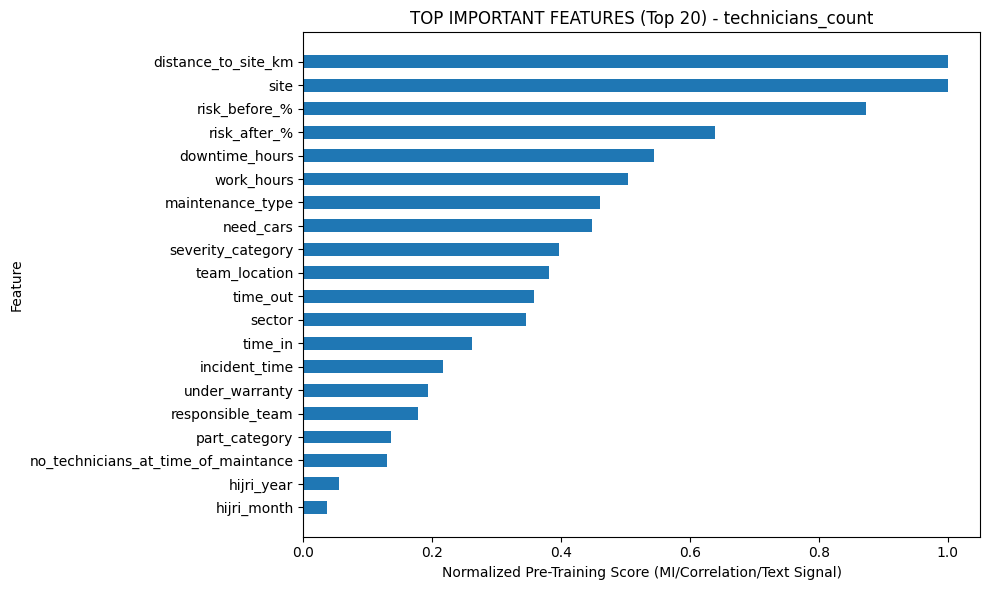

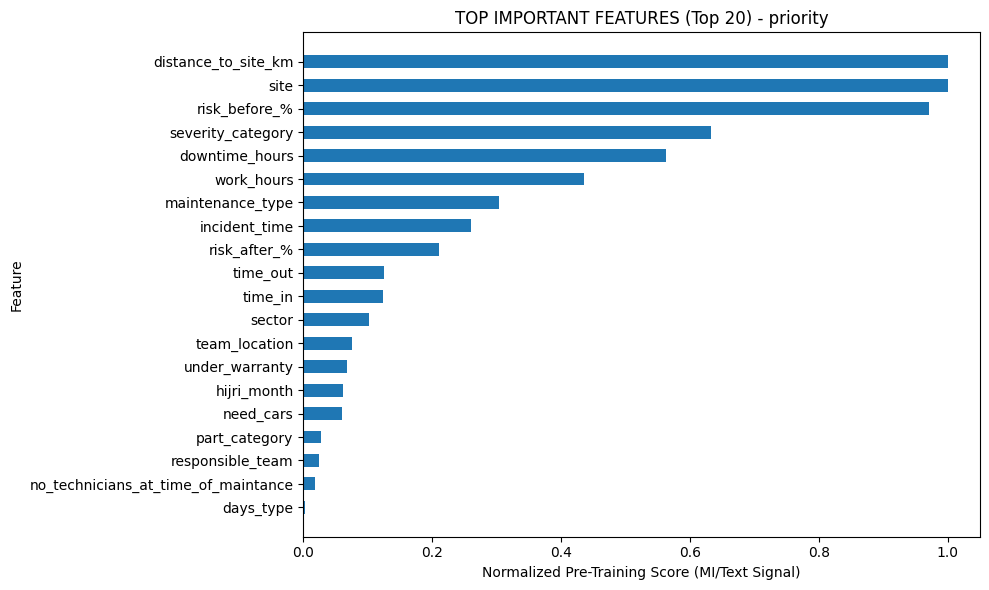

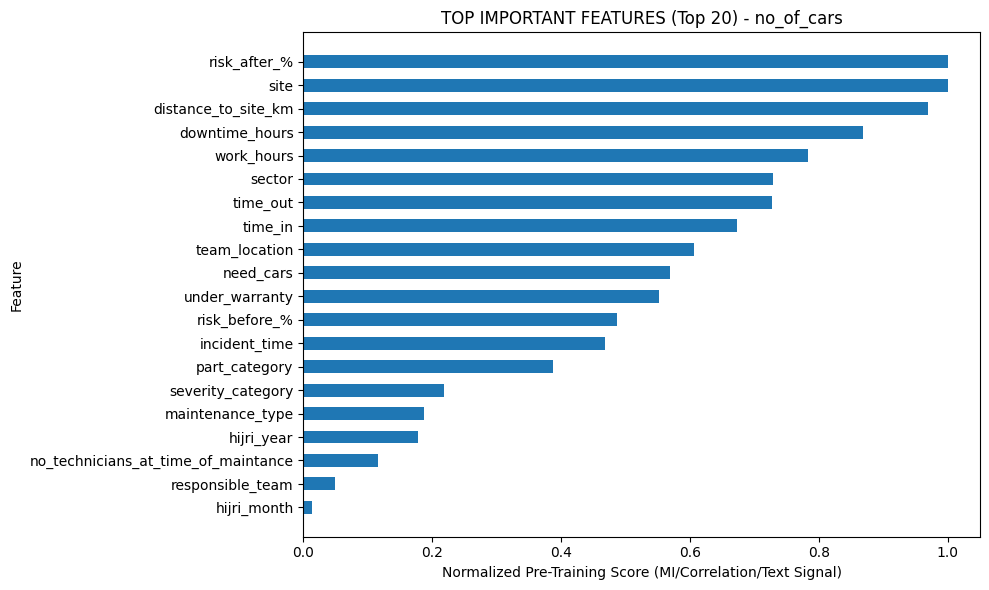

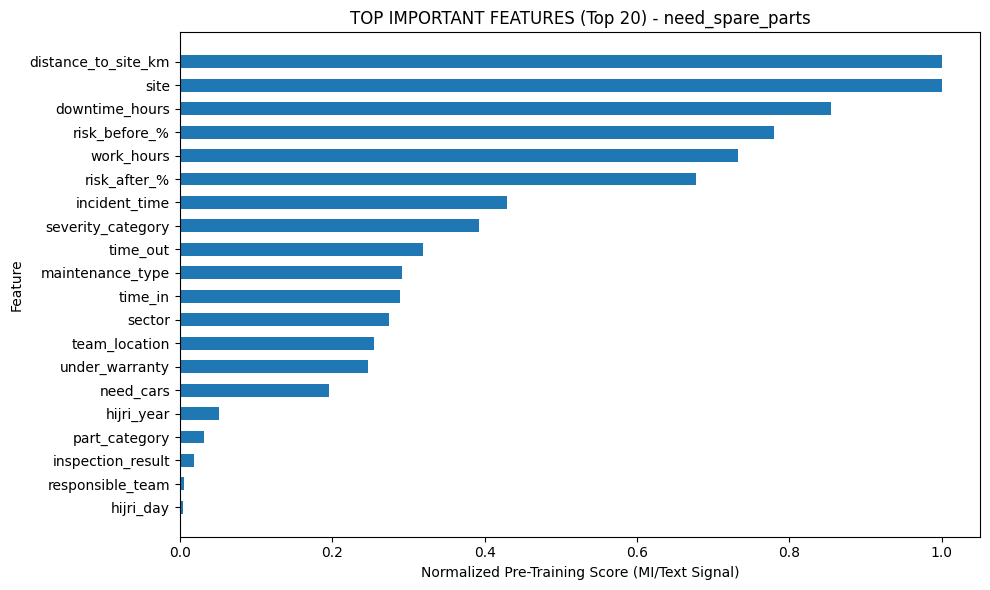

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# ✅ K-Fold imports
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error


# ============================================================
# 0) CONFIG
# ============================================================

DATA_PATH = "/content/maintence_dataset_final_hijri_added_and0prio.xlsx"
RANDOM_STATE = 42

TARGET_PRIORITY  = "priority"
TARGET_TECHCOUNT = "technicians_count"

# ✅ NEW TARGETS (added; everything else stays in same order)
TARGET_TRUCKS    = "no_of_cars"        # trucks/cars count
TARGET_SPARE     = "need_spare_parts"  # needs spare parts? (yes/no)

TEXT_COL = "fault_alarmandactivity"

# FEATURES (your requested minimal inputs)
CAT_COLS = ["site", "severity_category"]
NUM_COLS = ["no_technicians_at_time_of_maintance"]  # ⚠ leakage risk for priority

TOP_EDA_PLOTS = [
    "day", "month", "year", "priority",
    "no_technicians_at_time_of_maintance",
    "no_of_cars", "technicians_count",
    "downtime_hours", "work_hours",
    "labor_cost", "parts_cost",
    "risk_before_%", "risk_after_%"
]

HEATMAP_COLS = [
    "priority", "technicians_count", "no_technicians_at_time_of_maintance",
    "distance_to_site_km", "downtime_hours", "work_hours",
    "labor_cost", "parts_cost", "risk_before_%", "risk_after_%"
]

TOP_PRETRAIN = 20


# ============================================================
# 1) LOAD + CLEAN
# ============================================================

def clean_column_name(c: str) -> str:
    c = str(c).strip().replace("\n", " ")
    while "  " in c:
        c = c.replace("  ", " ")
    return c

def resolve_tech_at_time_column(df: pd.DataFrame) -> pd.DataFrame:
    a = "no_technicians_at_time_of_maintance"
    b = "no_technicians_at_time_of_maintenance"
    if a not in df.columns and b in df.columns:
        df = df.rename(columns={b: a})
    return df

df = pd.read_excel(DATA_PATH)
df = df.rename(columns={c: clean_column_name(c) for c in df.columns})
df = resolve_tech_at_time_column(df)
df = df.drop_duplicates()

print("✅ Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

if TEXT_COL not in df.columns:
    raise ValueError(f"Missing required text column: {TEXT_COL}")

# Keep only existing feature columns
CAT_COLS = [c for c in CAT_COLS if c in df.columns]
NUM_COLS = [c for c in NUM_COLS if c in df.columns]

print("\n✅ Using Features:")
print("NUM_COLS:", NUM_COLS)
print("CAT_COLS:", CAT_COLS)
print("TEXT_COL:", TEXT_COL)

display(df.head())


# ============================================================
# 2) DATASET SUMMARY (EDA TABLE)
# ============================================================

eda_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique()
}).reset_index(drop=True)

print("\n✅ Dataset Summary Table")
display(eda_summary)


# ============================================================
# 3) QUICK EDA PLOTS
# ============================================================

def _to_numeric(series):
    return pd.to_numeric(series, errors="coerce")

def plot_hist(ax, s, title, bins=30):
    s = _to_numeric(pd.Series(s)).dropna()
    if len(s) == 0:
        ax.axis("off")
        return
    ax.hist(
        s,
        bins=bins,
        linewidth=0.1,
        edgecolor="black"
    )
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="both", labelsize=8)

def plot_bar_counts(ax, s, title, rotate=45):
    s = pd.Series(s).dropna()
    s_num = pd.to_numeric(s, errors="coerce")

    if s_num.notna().sum() > 0:
        counts = s_num.dropna().value_counts().sort_index()
        labels = counts.index.astype(str).tolist()
        values = counts.values
    else:
        counts = s.astype(str).value_counts().head(20)
        labels = counts.index.astype(str).tolist()
        values = counts.values

    ax.bar(
        range(len(labels)),
        values,
        width=0.1,
        linewidth=0.4,
        edgecolor="black"
    )
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="both", labelsize=8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=rotate, ha="right")

cols_exist = [c for c in TOP_EDA_PLOTS if c in df.columns]
n = len(cols_exist)

rows, cols = 3, 4
fig, axes = plt.subplots(rows, cols, figsize=(14, 7))
plt.suptitle("EDA Snapshot", fontsize=14)

k = 0
for r in range(rows):
    for c in range(cols):
        ax = axes[r, c]
        if k >= n:
            ax.axis("off")
            continue
        col = cols_exist[k]
        unique_vals = df[col].nunique(dropna=True)
        if unique_vals <= 15:
            plot_bar_counts(ax, df[col], col)
        else:
            plot_hist(ax, df[col], col)
        k += 1

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# ============================================================
# 4) CORRELATION HEATMAP (WITH VALUES)
# ============================================================

def corr_heatmap_with_values(df_in: pd.DataFrame, title: str):
    corr = df_in.corr(numeric_only=True)
    cols = corr.columns.tolist()

    plt.figure(figsize=(11, 7))
    im = plt.imshow(corr, vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
    plt.yticks(range(len(cols)), cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            v = corr.iloc[i, j]
            if not np.isnan(v):
                plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)

    plt.title(title)
    plt.tight_layout()
    plt.show()

df_heat = df.copy()

if TARGET_PRIORITY in df_heat.columns:
    df_heat[TARGET_PRIORITY] = pd.to_numeric(df_heat[TARGET_PRIORITY], errors="coerce")
if TARGET_TECHCOUNT in df_heat.columns:
    df_heat[TARGET_TECHCOUNT] = pd.to_numeric(df_heat[TARGET_TECHCOUNT], errors="coerce")
if TARGET_TRUCKS in df_heat.columns:
    df_heat[TARGET_TRUCKS] = pd.to_numeric(df_heat[TARGET_TRUCKS], errors="coerce")

spare_num_col = "need_spare_parts_num"
if TARGET_SPARE in df_heat.columns:
    s = df_heat[TARGET_SPARE].astype(str).str.strip().str.lower()
    s = s.replace({"nan": np.nan, "none": np.nan, "": np.nan})

    yes_set = {"yes", "y", "true", "1", "need", "needed"}
    no_set  = {"no", "n", "false", "0", "not needed", "none"}

    df_heat[spare_num_col] = np.where(s.isin(yes_set), 1,
                               np.where(s.isin(no_set), 0, np.nan))
else:
    df_heat[spare_num_col] = np.nan

HEATMAP_COLS_4OUT = [
    TARGET_PRIORITY,
    TARGET_TECHCOUNT,
    TARGET_TRUCKS,
    spare_num_col,

    "no_technicians_at_time_of_maintance",
    "distance_to_site_km",
    "downtime_hours",
    "work_hours",
    "labor_cost",
    "parts_cost",
    "risk_before_%",
    "risk_after_%"
]

heat_cols = [c for c in HEATMAP_COLS_4OUT if c in df_heat.columns]
df_heat_final = df_heat[heat_cols].apply(pd.to_numeric, errors="coerce")

corr_heatmap_with_values(
    df_heat_final,
    "Correlation Heatmap (with values) — 4 Outputs Included"
)

print(f"✅ Note: '{spare_num_col}' is encoded from '{TARGET_SPARE}' as 0/1 for correlation.")


# ============================================================
# 5) TOP IMPORTANT FEATURES
# ============================================================

def to_numeric_if_possible(s: pd.Series) -> pd.Series:
    if s.dtype == "object":
        s2 = pd.to_numeric(
            s.astype(str).str.replace(",", "", regex=False).str.strip(),
            errors="coerce"
        )
        if s2.notna().mean() > 0.5:
            return s2
    return s

df_pre = df.copy()

df_pre[TARGET_TECHCOUNT] = pd.to_numeric(df_pre.get(TARGET_TECHCOUNT), errors="coerce")
df_pre[TARGET_PRIORITY]  = pd.to_numeric(df_pre.get(TARGET_PRIORITY),  errors="coerce")
df_pre[TARGET_TRUCKS]    = pd.to_numeric(df_pre.get(TARGET_TRUCKS),    errors="coerce")

df_pre[TEXT_COL] = df_pre[TEXT_COL].fillna("").astype(str)

for col in df_pre.columns:
    df_pre[col] = to_numeric_if_possible(df_pre[col])

exclude_pre = {TARGET_TECHCOUNT, TARGET_PRIORITY, TARGET_TRUCKS, TARGET_SPARE, "ticket_number"}
feature_cols_pre = [c for c in df_pre.columns if c not in exclude_pre]

num_cols_pre = [c for c in feature_cols_pre if (c != TEXT_COL and pd.api.types.is_numeric_dtype(df_pre[c]))]
cat_cols_pre = [c for c in feature_cols_pre if (c != TEXT_COL and not pd.api.types.is_numeric_dtype(df_pre[c]))]

print("\n✅ Pre-training candidates:")
print("Numeric cols:", len(num_cols_pre))
print("Categorical cols:", len(cat_cols_pre))
print("Text col:", TEXT_COL)

def rank_features_pretraining(df_in: pd.DataFrame, target: str, task: str, top_k: int = 20):
    assert task in {"reg", "clf"}

    data = df_in.dropna(subset=[target]).copy()
    y = data[target].values

    scores = []

    if len(num_cols_pre) > 0:
        X_num = data[num_cols_pre].copy()
        X_num = X_num.fillna(X_num.median(numeric_only=True))

        if task == "reg":
            mi = mutual_info_regression(X_num, y, random_state=42)
            corr = []
            for c in num_cols_pre:
                v = X_num[c].values
                corr.append(abs(np.corrcoef(v, y)[0, 1]) if np.std(v) > 0 else 0.0)
            corr = np.array(corr)
        else:
            y_int = pd.Series(y).astype(int).values
            mi = mutual_info_classif(X_num, y_int, random_state=42)
            corr = np.zeros(len(num_cols_pre))

        mi_n = (mi - mi.min()) / (mi.max() - mi.min() + 1e-9)

        if task == "reg":
            corr_n = (corr - corr.min()) / (corr.max() - corr.min() + 1e-9)
            combined_num = 0.7 * mi_n + 0.3 * corr_n
        else:
            combined_num = mi_n

        for c, sc in zip(num_cols_pre, combined_num):
            scores.append((c, float(sc), "numeric"))

    if len(cat_cols_pre) > 0:
        for c in cat_cols_pre:
            s = data[c].fillna("missing").astype(str)
            le = LabelEncoder()
            x = le.fit_transform(s).reshape(-1, 1)

            if task == "reg":
                mi = mutual_info_regression(x, y, random_state=42)[0]
            else:
                y_int = pd.Series(y).astype(int).values
                mi = mutual_info_classif(x, y_int, random_state=42)[0]

            scores.append((c, float(mi), "categorical"))

    if TEXT_COL in data.columns:
        text = data[TEXT_COL].fillna("").astype(str).values
        tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
        X_text = tfidf.fit_transform(text)
        text_strength = float(np.mean(X_text.mean(axis=1)))
        scores.append((TEXT_COL, text_strength, "text"))

    out = pd.DataFrame(scores, columns=["feature", "raw_score", "type"])

    out["score"] = 0.0
    for t in out["type"].unique():
        m = out.loc[out["type"] == t, "raw_score"]
        out.loc[out["type"] == t, "score"] = (m - m.min()) / (m.max() - m.min() + 1e-9)

    out = out.sort_values("score", ascending=False).head(top_k).reset_index(drop=True)
    return out[["feature", "score", "type"]]

top20_pre_tech   = rank_features_pretraining(df_pre, TARGET_TECHCOUNT, task="reg", top_k=TOP_PRETRAIN)
top20_pre_prio   = rank_features_pretraining(df_pre, TARGET_PRIORITY,  task="clf", top_k=TOP_PRETRAIN)
top20_pre_trucks = rank_features_pretraining(df_pre, TARGET_TRUCKS,    task="reg", top_k=TOP_PRETRAIN)

if TARGET_SPARE in df_pre.columns:
    y_spare_raw = df_pre[TARGET_SPARE].astype(str).str.strip().str.lower()
    y_spare_raw = y_spare_raw.replace({"nan": np.nan, "none": np.nan, "": np.nan})

    df_pre_spare_rank = df_pre.copy()
    df_pre_spare_rank["y_spare_rank"] = y_spare_raw
    df_pre_spare_rank = df_pre_spare_rank.dropna(subset=["y_spare_rank"]).copy()

    le_spare = LabelEncoder()
    df_pre_spare_rank["y_spare_rank"] = le_spare.fit_transform(df_pre_spare_rank["y_spare_rank"])

    top20_pre_spare = rank_features_pretraining(
        df_pre_spare_rank,
        target="y_spare_rank",
        task="clf",
        top_k=TOP_PRETRAIN
    )
else:
    top20_pre_spare = pd.DataFrame(columns=["feature", "score", "type"])

print("\n===== TOP 20 (TOP IMPORTANT FEATURES) for technicians_count =====")
display(top20_pre_tech)

print("\n===== TOP 20 (TOP IMPORTANT FEATURES) for priority =====")
display(top20_pre_prio)

print("\n===== TOP 20 (TOP IMPORTANT FEATURES) for no_of_cars =====")
display(top20_pre_trucks)

print("\n===== TOP 20 (TOP IMPORTANT FEATURES) for need_spare_parts =====")
display(top20_pre_spare)

def plot_top_features(df_rank: pd.DataFrame, title: str, xlabel: str):
    df_plot = df_rank.sort_values("score", ascending=True)
    plt.figure(figsize=(10, 6))
    plt.barh(df_plot["feature"], df_plot["score"], height=0.55)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

plot_top_features(
    top20_pre_tech,
    title=f"TOP IMPORTANT FEATURES (Top {len(top20_pre_tech)}) - technicians_count",
    xlabel="Normalized Pre-Training Score (MI/Correlation/Text Signal)"
)

plot_top_features(
    top20_pre_prio,
    title=f"TOP IMPORTANT FEATURES (Top {len(top20_pre_prio)}) - priority",
    xlabel="Normalized Pre-Training Score (MI/Text Signal)"
)

plot_top_features(
    top20_pre_trucks,
    title=f"TOP IMPORTANT FEATURES (Top {len(top20_pre_trucks)}) - no_of_cars",
    xlabel="Normalized Pre-Training Score (MI/Correlation/Text Signal)"
)

if len(top20_pre_spare) > 0:
    plot_top_features(
        top20_pre_spare,
        title=f"TOP IMPORTANT FEATURES (Top {len(top20_pre_spare)}) - need_spare_parts",
        xlabel="Normalized Pre-Training Score (MI/Text Signal)"
    )


